In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = 'Qwen/Qwen2.5-1.5B-Instruct'
AutoTokenizer.from_pretrained(MODEL_NAME)
AutoModelForCausalLM.from_pretrained(MODEL_NAME)
print("✅ Cached!")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

✅ Cached!


In [ ]:
import copy
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, StaticCache

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

MODEL_NAME = 'Qwen/Qwen2.5-1.5B-Instruct'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, local_files_only=True)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16, local_files_only=True)
model = model.to(device)
model.eval()

# Pre-compute token IDs for Yes and No once
YES_ID = tokenizer.encode('Yes', add_special_tokens=False)[0]
NO_ID = tokenizer.encode('No', add_special_tokens=False)[0]


def get_system_promt(k=3):
    system_prompt = f"You are a classifier. Answer only Yes or No. Is the given number a multiple of {k}?"
    return system_prompt

def get_file_name(k=3):
    return f"LLM_mod_{k}.csv"



`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [3]:
def classify_batch(user_messages: list[str], system_prompt: str) -> list[dict]:
    print(system_prompt)
    # Tokenize each full conversation individually
    all_ids = [
        tokenizer.apply_chat_template(
            [{"role": "system", "content": system_prompt},
             {"role": "user",   "content": m}],
            return_tensors="pt",
            add_generation_prompt=True,
            tokenize=True,
            return_dict=False,
        ).squeeze(0)
        for m in user_messages
    ]

    # Left-pad so all sequences end at the same position (decoder models are right-aligned)
    padded = torch.nn.utils.rnn.pad_sequence(
        [t.flip(0) for t in all_ids],
        batch_first=True,
        padding_value=tokenizer.pad_token_id,
    ).flip(1).to(device)
    attention_mask = (padded != tokenizer.pad_token_id).long()

    with torch.no_grad():
        outputs = model(padded, attention_mask=attention_mask)

    # For each item in the batch, read logits at its last real token
    results = []
    seq_lengths = attention_mask.sum(dim=1)  # actual length per item
    for idx in range(len(user_messages)):
        last_pos = seq_lengths[idx] - 1
        logits = outputs.logits[idx, last_pos, :]
        probs = torch.softmax(torch.stack([logits[YES_ID], logits[NO_ID]]), dim=0)
        results.append({
            'answer': 'Yes' if probs[0] > probs[1] else 'No',
            'P(Yes)': round(probs[0].item(), 3),
            'P(No)':  round(probs[1].item(), 3),
        })
    return results





In [ ]:
import pandas as pd
from pathlib import Path
import os
def gather_data(data_range:list[int], k:int=3):
    csv_file_name = get_file_name(k)
    system_prompt = get_system_promt(k)
    columns = ["Query", "Output", "P(Yes)", "P(No)", "P(err)"]
    if not Path(csv_file_name).exists():
        df = pd.DataFrame(columns=columns)
    else:
        df = pd.read_csv(csv_file_name)

    new_rows = []
    all_mgs = [str(j) for j in data_range if j not in df["Query"]]
    if not all_mgs:
        return
    answers = classify_batch(user_messages=all_mgs,system_prompt=system_prompt)
    for result, query in zip(answers, all_mgs):
        wrong_answer = "No" if int(query)% k == 0 else "Yes"
        new_row = {"Query": int(query),
                   "Output": result["answer"],
                   "P(Yes)": result["P(Yes)"],
                   "P(No)": result["P(No)"],
                   "P(err)": result[f"P({wrong_answer})"]}

        new_rows.append(new_row)


    

    new_df = pd.DataFrame(new_rows)
    
    
    df = pd.concat([df,new_df], ignore_index=True)
    df.to_csv(csv_file_name, index=False)


gather_data(list(range(400)))

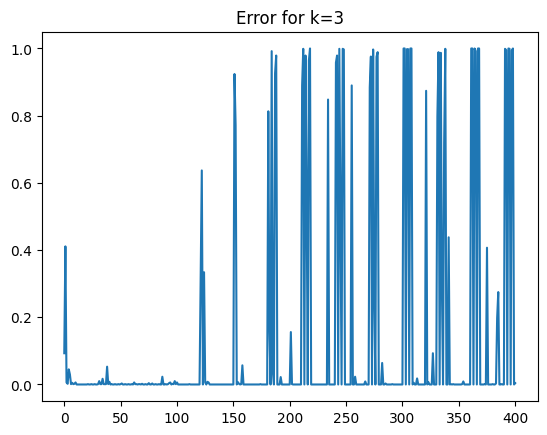

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
from pathlib import Path

def plot_avilable_data(k:int=3, min_x=float("-inf"),max_x=float("inf")):
    csv_file_name = get_file_name(k)
    if not Path(csv_file_name).exists():
        raise FileExistsError("No such file found: ", csv_file_name)
    df = pd.read_csv(csv_file_name)
    df_filtered = df[(df["Query"] <= max_x) & (min_x <= df["Query"])]
    y = df_filtered["P(err)"]
    x = df_filtered["Query"]

    plt.plot(x,y)
    plt.title(f"Error for k={k}")
    plt.show()
plot_avilable_data(min_x=0,max_x=400)

In [6]:
for k in range(1,11):
    gather_data(list(range(500)),k=k)

You are a classifier. Answer only Yes or No. Is the given number a multiple of 1?


In [7]:
gather_data(list(range(500)))

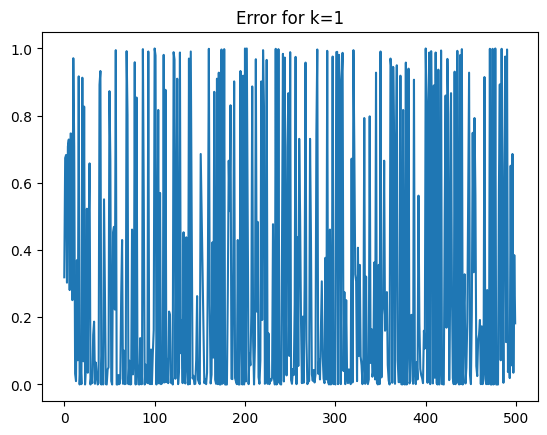

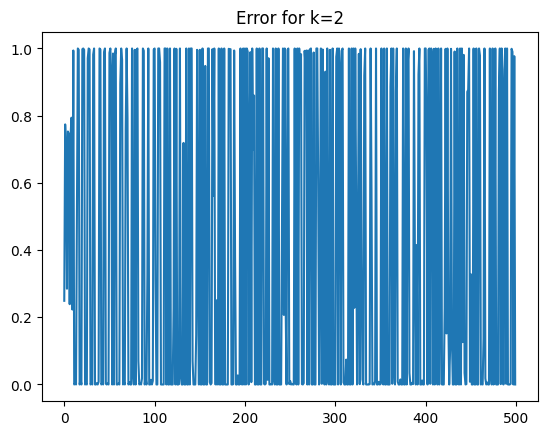

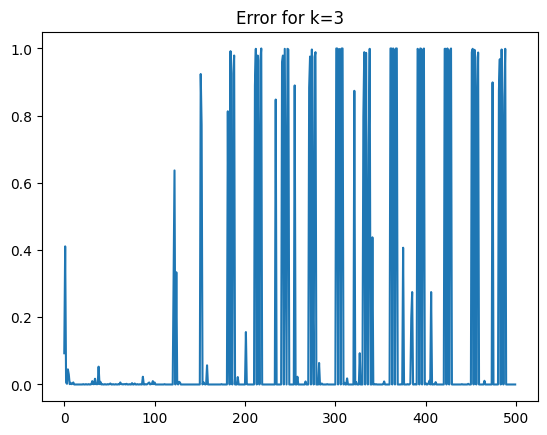

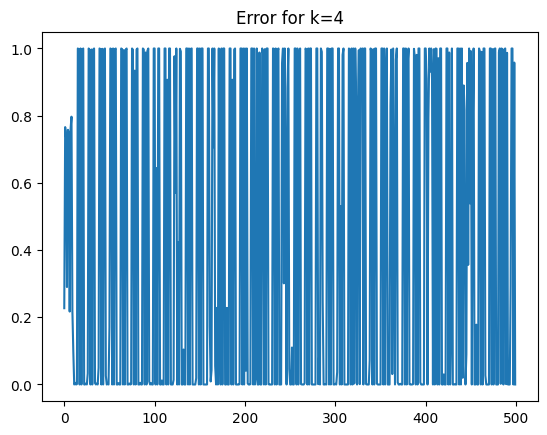

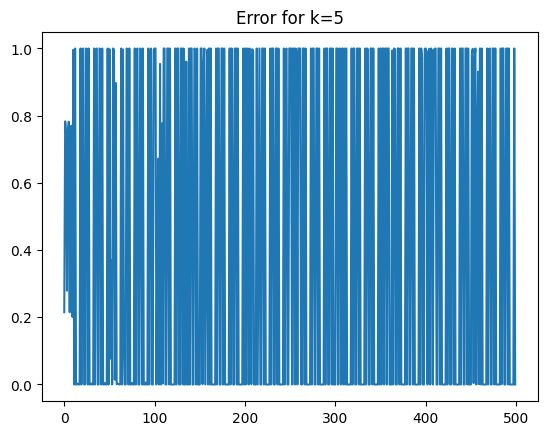

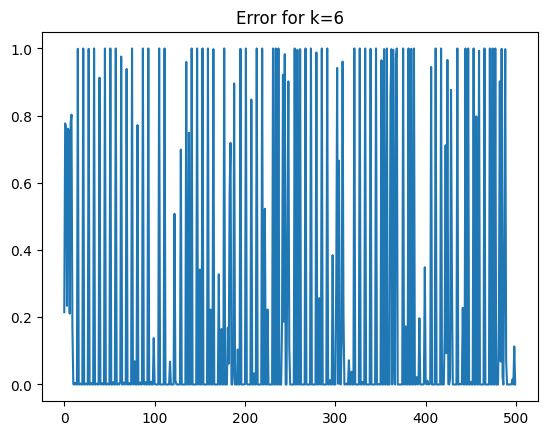

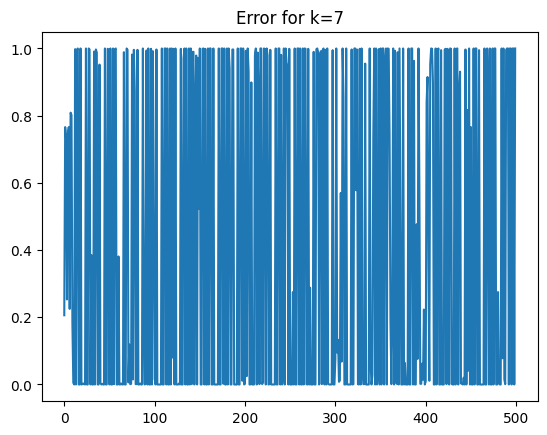

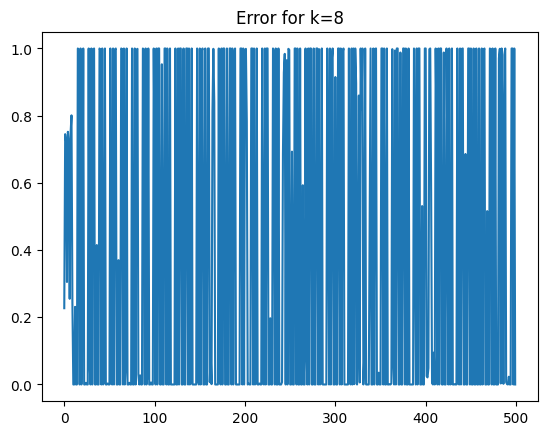

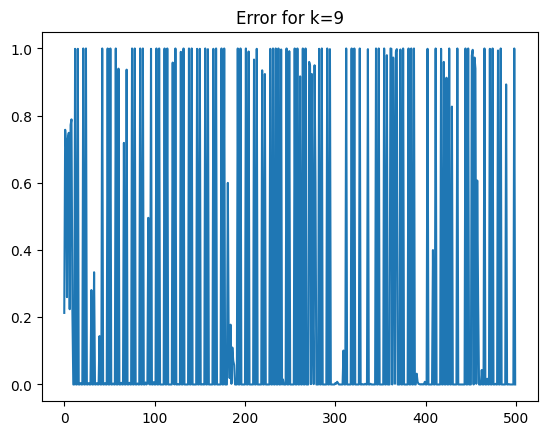

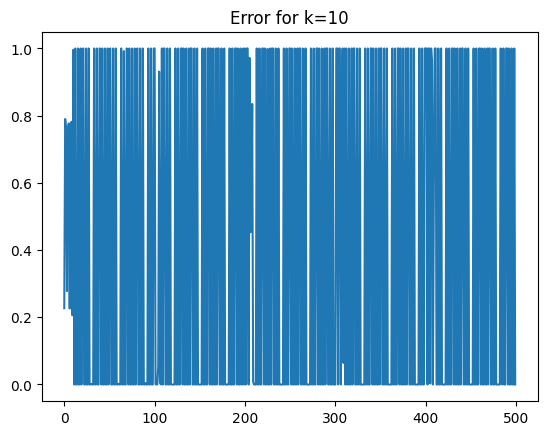

In [8]:
for k in range(1,11):
    plot_avilable_data(k)